# NIS: Neural Image Stitching — 出力例

WACV'24 [*Implicit Neural Image Stitching With Enhanced and Blended Feature Reconstruction*](https://arxiv.org/abs/2309.01409) の pretrained モデルで、
リポジトリ同梱の `left.jpg` / `right.jpg` を合成した出力例です。

| 項目 | 内容 |
| --- | --- |
| 画像推定 | `pretrained/ihn.pth` (Homography Estimator) |
| 合成 | `pretrained/NIS_blending.pth` (Enhanced & Blended, Stage 1+2) |
| 実行環境 | pixi env (`pixi install` → `pixi run setup`) |

VRAM 8 GiB でも実行できるように入力を `SCALE` 倍に縮小しています（`SCALE = 1.0` で原寸 1008×756、要 11 GiB+）。

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import yaml
from PIL import Image
from torchvision import transforms

# notebooks/ からでもリポジトリ直下からでも動くようにする
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})

print("repo     :", REPO_ROOT)
print("torch    :", torch.__version__, "| cuda:", torch.version.cuda)
print("gpu      :", torch.cuda.get_device_name(0))

/home/inaho-omen/Project/Neural-Image-Stitching/.pixi/envs/default/lib/python3.9/site-packages/torch/torch_version.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


repo     : /home/inaho-omen/Project/Neural-Image-Stitching
torch    : 1.10.2 | cuda: 11.3
gpu      : NVIDIA GeForce GTX 1070


## 入力画像

`left.jpg` を基準フレーム (ref)、`right.jpg` を入力 (tgt) として渡します。

In [2]:
SCALE = 0.5  # 8 GiB VRAM 向け。原寸で実行する場合は 1.0 に変更

def load_input(path, scale):
    image = Image.open(path).convert("RGB")
    if scale != 1.0:
        size = (round(image.width * scale), round(image.height * scale))
        image = image.resize(size, Image.LANCZOS)
    return image

ref_img = load_input(REPO_ROOT / "left.jpg", SCALE)
tgt_img = load_input(REPO_ROOT / "right.jpg", SCALE)

ref = transforms.ToTensor()(ref_img).cuda().unsqueeze(0)
tgt = transforms.ToTensor()(tgt_img).cuda().unsqueeze(0)
print(f"left : {ref_img.width}x{ref_img.height}  right: {tgt_img.width}x{tgt_img.height}")

left : 504x378  right: 504x378


## 推論（ホモグラフィ推定 → 合成）

`stitch.py` の `prepare_validation` / `valid` をそのまま呼び出します。結果は `results.png` に保存されます。

In [3]:
import stitch

with open(REPO_ROOT / "configs/test/NIS_blending.yaml") as f:
    config = yaml.safe_load(f)
stitch.config = config

model, H_model = stitch.prepare_validation(config)

start = time.time()
with torch.no_grad():
    stitch.valid(model, H_model, ref, tgt)
elapsed = time.time() - start

stitched = Image.open(REPO_ROOT / "results.png").convert("RGB")
print(f"stitched: {stitched.width}x{stitched.height}  ({elapsed:.1f} s on {torch.cuda.get_device_name(0)})")

/home/inaho-omen/Project/Neural-Image-Stitching/.pixi/envs/default/lib/python3.9/site-packages/torch/nn/functional.py:3631: UserWarning: Default upsampling behavior when mode=bilinear is changed to align_corners=False since 0.4.0. Please specify align_corners=True if the old behavior is desired. See the documentation of nn.Upsample for details.
  warnings.warn(


/home/inaho-omen/Project/Neural-Image-Stitching/.pixi/envs/default/lib/python3.9/site-packages/torch/functional.py:445: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  /opt/conda/conda-bld/pytorch_1640811803361/work/aten/src/ATen/native/TensorShape.cpp:2157.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


/home/inaho-omen/Project/Neural-Image-Stitching/.pixi/envs/default/lib/python3.9/site-packages/torch/nn/functional.py:3847: UserWarning: nn.functional.upsample_bilinear is deprecated. Use nn.functional.interpolate instead.
  warnings.warn("nn.functional.upsample_bilinear is deprecated. Use nn.functional.interpolate instead.")


stitched: 802x469  (7.1 s on NVIDIA GeForce GTX 1070)


## 合成結果

上段が入力ペア、下段がモデル出力（パノラマ）です。

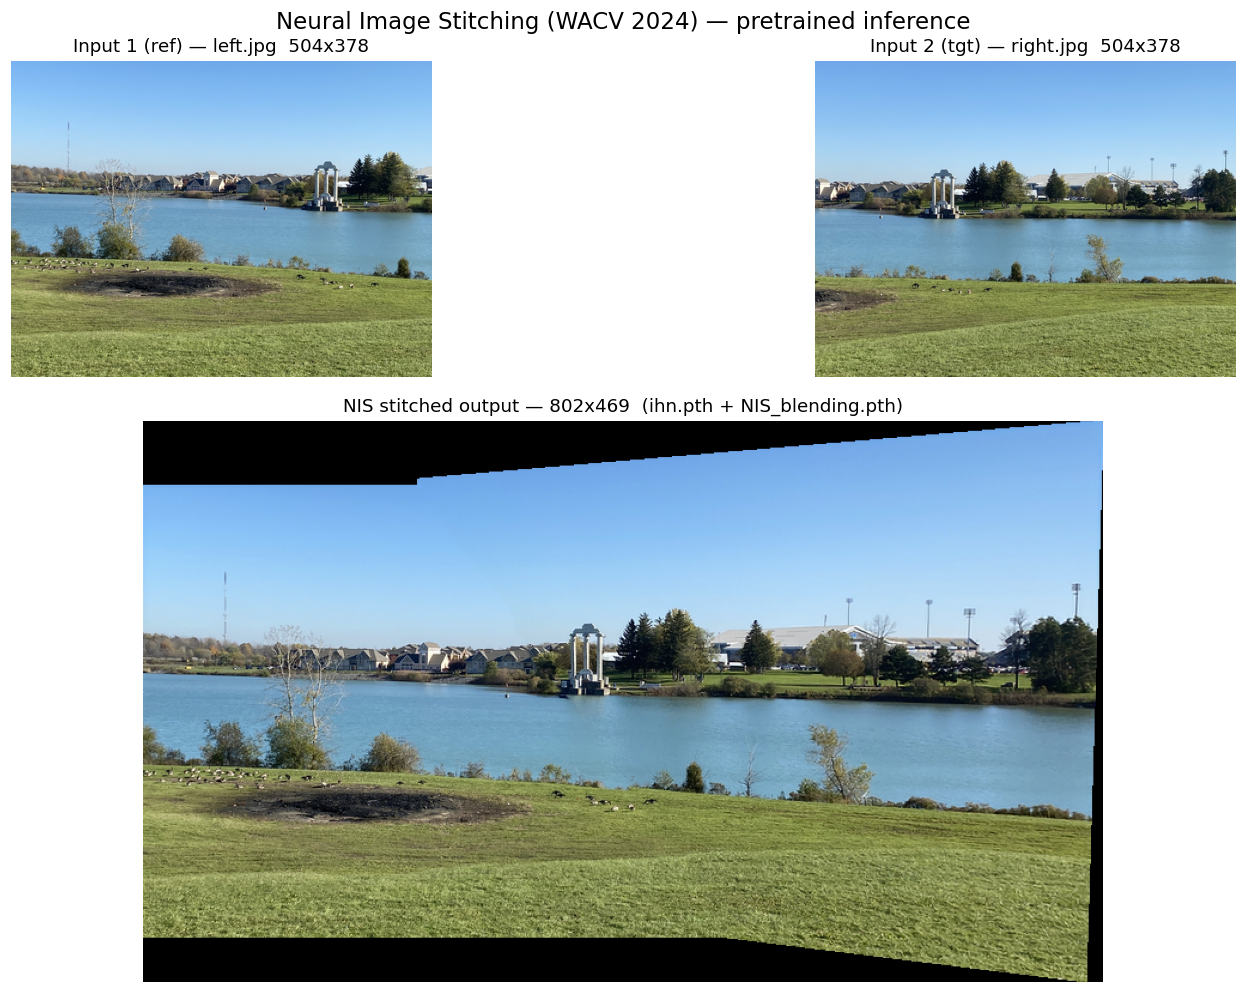

In [4]:
fig = plt.figure(figsize=(15, 9.2))
gs = fig.add_gridspec(2, 2, height_ratios=[0.36, 0.64], hspace=0.10, wspace=0.03)

ax_l = fig.add_subplot(gs[0, 0])
ax_r = fig.add_subplot(gs[0, 1])
ax_s = fig.add_subplot(gs[1, :])

ax_l.imshow(ref_img)
ax_l.set_title(f"Input 1 (ref) — left.jpg  {ref_img.width}x{ref_img.height}", fontsize=12)
ax_r.imshow(tgt_img)
ax_r.set_title(f"Input 2 (tgt) — right.jpg  {tgt_img.width}x{tgt_img.height}", fontsize=12)
ax_s.imshow(stitched)
ax_s.set_title(f"NIS stitched output — {stitched.width}x{stitched.height}  (ihn.pth + NIS_blending.pth)", fontsize=12)

for ax in (ax_l, ax_r, ax_s):
    ax.set_axis_off()

fig.suptitle("Neural Image Stitching (WACV 2024) — pretrained inference", fontsize=15)
fig.subplots_adjust(top=0.93, bottom=0.02, left=0.02, right=0.98)
plt.show()

## ディテール確認（等倍クロップ）

パノラマを左・中央・右の 3 領域に分けて等倍で表示し、重なり部分の位置合わせとブレンドを確認します。

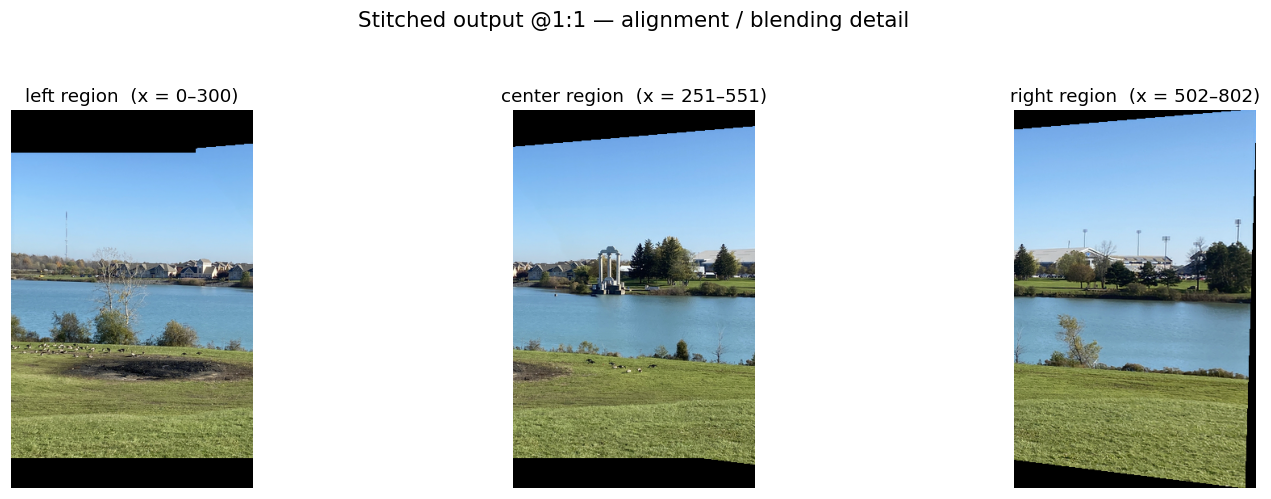

In [5]:
w, h = stitched.size
crop_w = 300
left_edges = [0, (w - crop_w) // 2, w - crop_w]
labels = ["left region", "center region", "right region"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, x0, label in zip(axes, left_edges, labels):
    ax.imshow(stitched.crop((x0, 0, x0 + crop_w, h)))
    ax.set_title(f"{label}  (x = {x0}–{x0 + crop_w})", fontsize=12)
    ax.set_axis_off()

fig.suptitle("Stitched output @1:1 — alignment / blending detail", fontsize=14)
fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

## メモ

- 出力四隅の黒い領域は stitch マスク外（キャンバス外）で、入力画像が存在しない範囲です。
- 重なり領域は `cv2.detail.SeamFinder` によるシーム選択 + モデルのブレンドで処理されます。
- 原寸 (`SCALE = 1.0`) は VRAM 8 GiB では Out-of-Memory になります。`pixi run test-e2e-full` も同じ理由でより大きな GPU が必要です。